# Gas Storage Valuation

Value a natural gas storage lease two ways: the **intrinsic** value locked against today's forward curve (a linear program), and the **rolling intrinsic** value from re-optimizing as simulated spot prices move (Monte Carlo around the same LP). The difference is a lower bound on the storage's extrinsic (option) value.

This notebook is the formulation companion to the [live app](https://gas-storage.griffith-pse.com).

## The product

A storage lease grants the right to inject, hold, and withdraw gas over a contract year (April to March), subject to a working-gas capacity, weekly rate limits, variable costs, and a fuel loss on injection. The facility starts and ends empty.

## Intrinsic value: a linear program

**Decision variables**: $i_t$ = gas injected during week $t$ (k MMBtu), $w_t$ = gas withdrawn during week $t$, $v_t$ = inventory at the end of week $t$.

**Data**: $F_t$ = forward price for week $t$ (\$/MMBtu), $c_i, c_w$ = variable injection and withdrawal costs, $\phi$ = fuel-loss fraction, $V^{\max}$ = capacity, $I^{\max}, W^{\max}$ = weekly rate limits.

$$\begin{aligned}
\max_{i, w, v} \quad & \sum_{t=1}^{52} F_t (w_t - i_t) - c_i\, i_t - c_w\, w_t \\
\text{s.t.} \quad & v_t = v_{t-1} + (1-\phi)\, i_t - w_t, \qquad v_0 = 0,\; v_{52} = 0 \\
& 0 \le v_t \le V^{\max}, \quad 0 \le i_t \le I^{\max}, \quad 0 \le w_t \le W^{\max}
\end{aligned}$$

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pyomo.environ as pyo
from pyomo.contrib.appsi.solvers import Highs

WEEKS = 52

# Contract
CAPACITY = 1000.0   # working gas, k MMBtu
INJ_RATE = 60.0     # k MMBtu / week
WD_RATE = 100.0
INJ_COST = 0.02     # $/MMBtu
WD_COST = 0.02
FUEL = 0.01         # fuel-loss fraction on injection

# Market
BASE, PREMIUM = 3.50, 1.00   # $/MMBtu
SIGMA, KAPPA = 0.55, 6.0     # annualized log-vol, mean-reversion per year


def seasonal_curve(base=BASE, premium=PREMIUM):
    """Forward curve by week; the contract year runs April-March, so the
    winter peak (mid-January) sits at week ~41."""
    return base + premium * np.cos(2 * np.pi * (np.arange(WEEKS) - 41.5) / WEEKS)


curve = seasonal_curve()

In [2]:
def build_lp():
    """Storage LP with the forward curve as a mutable Param, so the Monte
    Carlo below can re-solve the same model hundreds of times."""
    m = pyo.ConcreteModel()
    m.T = pyo.RangeSet(0, WEEKS - 1)
    m.F = pyo.Param(m.T, mutable=True, initialize=0.0)
    m.i = pyo.Var(m.T, bounds=(0, INJ_RATE))
    m.w = pyo.Var(m.T, bounds=(0, WD_RATE))
    m.inv = pyo.Var(m.T, bounds=(0, CAPACITY))

    @m.Constraint(m.T)
    def balance(m, t):
        prev = 0.0 if t == 0 else m.inv[t - 1]
        return m.inv[t] == prev + (1 - FUEL) * m.i[t] - m.w[t]

    m.end_empty = pyo.Constraint(expr=m.inv[WEEKS - 1] == 0)
    m.obj = pyo.Objective(
        expr=sum(m.F[t] * (m.w[t] - m.i[t]) - INJ_COST * m.i[t] - WD_COST * m.w[t]
                 for t in m.T),
        sense=pyo.maximize)
    return m


def load_curve(m, F):
    for t in range(WEEKS):
        m.F[t] = float(F[t])


lp = build_lp()
load_curve(lp, curve)
opt = Highs()
opt.solve(lp)
intrinsic = pyo.value(lp.obj)
inv_plan = np.array([pyo.value(lp.inv[t]) for t in range(WEEKS)])
flow_plan = np.array([pyo.value(lp.i[t]) - pyo.value(lp.w[t]) for t in range(WEEKS)])
print(f"Intrinsic value: {intrinsic:,.1f} k$")

Intrinsic value: 1,709.0 k$


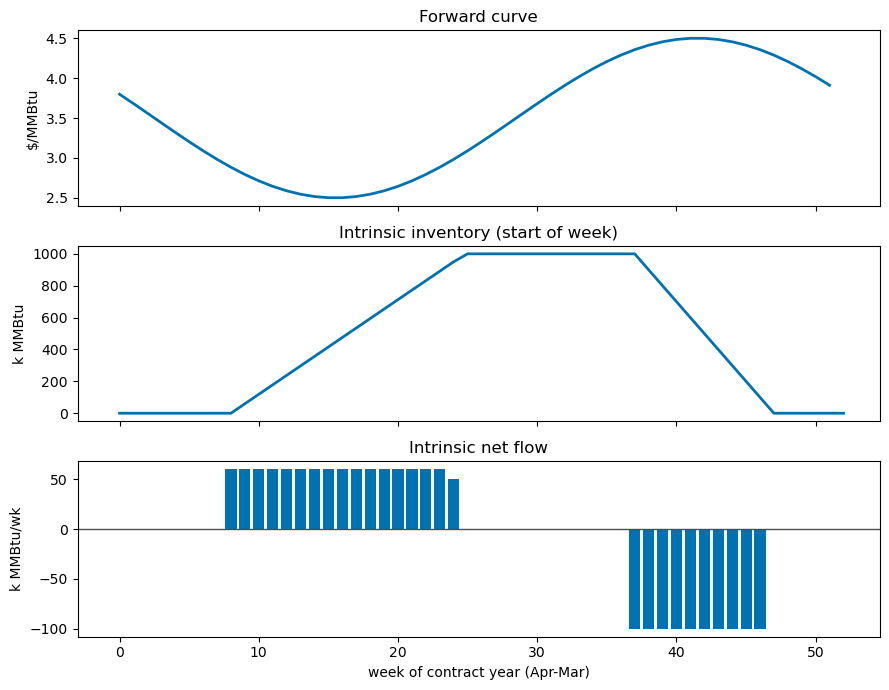

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
axes[0].plot(curve, color="#0072B2", lw=2)
axes[0].set_ylabel("$/MMBtu"); axes[0].set_title("Forward curve")
axes[1].plot(np.concatenate([[0], inv_plan]), color="#0072B2", lw=2)
axes[1].set_ylabel("k MMBtu"); axes[1].set_title("Intrinsic inventory (start of week)")
axes[2].bar(np.arange(WEEKS), flow_plan, color="#0072B2")
axes[2].axhline(0, color="0.3", lw=1)
axes[2].set_ylabel("k MMBtu/wk"); axes[2].set_title("Intrinsic net flow")
axes[2].set_xlabel("week of contract year (Apr-Mar)")
fig.tight_layout()

## Spot price process

Log spot mean-reverts around the seasonal curve $m(t)$ (a one-factor Schwartz model, in which the log deviation follows an Ornstein-Uhlenbeck (OU) process). With $S_t$ = spot price, $x_t = \ln(S_t/m(t))$ = the log deviation, $\kappa$ = mean-reversion speed, $\sigma$ = volatility, and $B_t$ = Brownian motion:

$$dx_t = -\kappa\, x_t\, dt + \sigma\, dB_t$$

Simulation uses the exact OU transition over each weekly step ($\varepsilon$ a standard normal draw):

$$x_{t+\Delta t} = e^{-\kappa \Delta t}\, x_t + \sigma\sqrt{\tfrac{1 - e^{-2\kappa \Delta t}}{2\kappa}}\; \varepsilon$$

The forward curve seen from week $t$ for delivery in week $d$ is the conditional expectation of spot, including the Jensen half-variance term:

$$F_t(d) = m(d)\, \exp\Big( x_t\, e^{-\kappa (d-t)} + \tfrac{1}{2}\,\mathrm{Var}[x_d \mid x_t] \Big), \qquad \mathrm{Var}[x_d \mid x_t] = \tfrac{\sigma^2}{2\kappa}\big(1 - e^{-2\kappa (d-t)}\big)$$

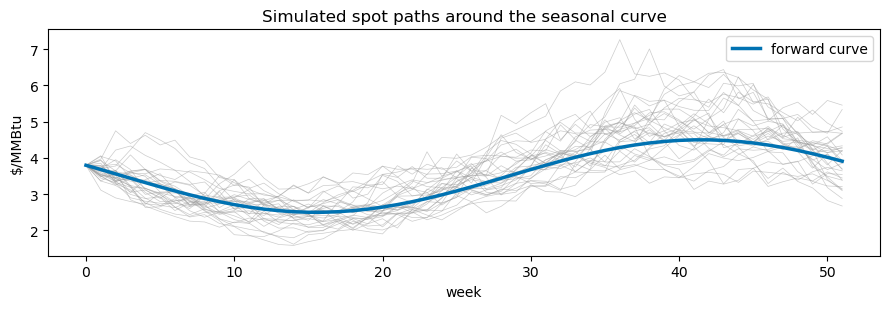

In [4]:
def simulate_spot(n_paths, seed=0):
    dt = 1.0 / WEEKS
    a = math.exp(-KAPPA * dt)
    s = SIGMA * math.sqrt((1 - a * a) / (2 * KAPPA))
    rng = np.random.default_rng(seed)
    x = np.zeros((n_paths, WEEKS))
    for t in range(1, WEEKS):
        x[:, t] = a * x[:, t - 1] + s * rng.standard_normal(n_paths)
    return curve[None, :] * np.exp(x)


def conditional_curve(spot_t, t):
    x_t = math.log(spot_t / curve[t])
    tau = (np.arange(t, WEEKS) - t) / WEEKS
    decay = np.exp(-KAPPA * tau)
    var = SIGMA**2 * (1 - np.exp(-2 * KAPPA * tau)) / (2 * KAPPA)
    out = curve.copy()
    out[t:] = curve[t:] * np.exp(x_t * decay + 0.5 * var)
    return out


spot = simulate_spot(200)
plt.figure(figsize=(9, 3.2))
plt.plot(spot[:30].T, color="0.6", lw=0.5, alpha=0.5)
plt.plot(curve, color="#0072B2", lw=2.5, label="forward curve")
plt.xlabel("week"); plt.ylabel("$/MMBtu"); plt.legend()
plt.title("Simulated spot paths around the seasonal curve")
plt.tight_layout()

## Rolling intrinsic

The industry-standard lower-bound estimate of full storage value:

1. Simulate a spot path.
2. Every 4 weeks, rebuild the conditional forward curve from the path's current spot.
3. Re-solve the intrinsic LP over the remaining horizon, with executed weeks locked at their committed flows.
4. Execute the plan's next 4 weeks at those prices; accumulate the realized value.
5. Average across paths.

Individual paths can realize less than intrinsic (the tail of the plan is exposed to price moves); on average, re-optimizing beats locking. In control-theory terms, intrinsic is the optimal open-loop plan and rolling intrinsic is certainty-equivalent model predictive control.

In [5]:
STEP = 4

def rolling_intrinsic(spot):
    m = build_lp()
    opt = Highs()
    n_paths = spot.shape[0]
    pnl = np.zeros(n_paths)
    for p in range(n_paths):
        for t0 in range(0, WEEKS, STEP):
            cond = conditional_curve(spot[p, t0], t0)
            load_curve(m, cond)
            opt.solve(m)
            for t in range(t0, min(t0 + STEP, WEEKS)):
                i_t = min(max(pyo.value(m.i[t]), 0.0), INJ_RATE)
                w_t = min(max(pyo.value(m.w[t]), 0.0), WD_RATE)
                pnl[p] += cond[t] * (w_t - i_t) - INJ_COST * i_t - WD_COST * w_t
                m.i[t].fix(i_t)
                m.w[t].fix(w_t)
        for t in range(WEEKS):
            m.i[t].unfix()
            m.w[t].unfix()
    return pnl


pnl = rolling_intrinsic(spot)
rolling = pnl.mean()
print(f"Intrinsic:         {intrinsic:8,.1f} k$")
print(f"Rolling intrinsic: {rolling:8,.1f} k$   ({len(pnl)} paths)")
print(f"Extrinsic uplift:  {rolling - intrinsic:+8,.1f} k$  (lower bound on extrinsic value)")

Intrinsic:          1,709.0 k$
Rolling intrinsic:  1,883.5 k$   (200 paths)
Extrinsic uplift:    +174.5 k$  (lower bound on extrinsic value)


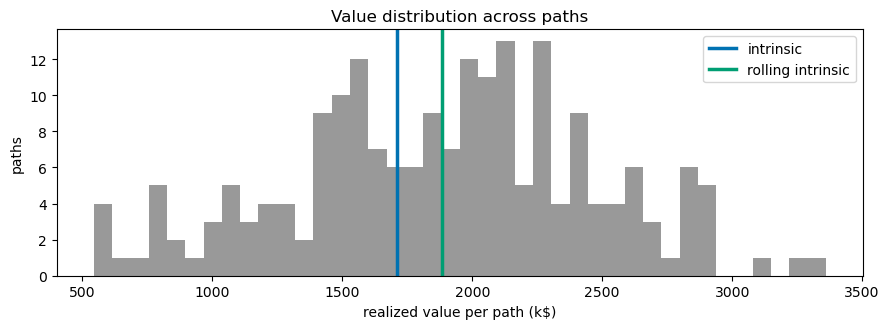

In [6]:
plt.figure(figsize=(9, 3.4))
plt.hist(pnl, bins=40, color="0.6")
plt.axvline(intrinsic, color="#0072B2", lw=2.5, label="intrinsic")
plt.axvline(rolling, color="#009E73", lw=2.5, label="rolling intrinsic")
plt.xlabel("realized value per path (k$)"); plt.ylabel("paths"); plt.legend()
plt.title("Value distribution across paths")
plt.tight_layout()

## Sanity check

As volatility goes to zero the spot paths collapse onto the forward curve, re-optimization finds nothing to improve, and rolling intrinsic must equal intrinsic.

In [7]:
SIGMA_SAVE = SIGMA
SIGMA = 1e-4
pnl0 = rolling_intrinsic(simulate_spot(10))
SIGMA = SIGMA_SAVE
print(f"rolling at sigma~0: {pnl0.mean():,.2f} k$  vs intrinsic {intrinsic:,.2f} k$")

rolling at sigma~0: 1,709.00 k$  vs intrinsic 1,709.03 k$


## References

[1] A. Boogert and C. de Jong, "Gas Storage Valuation Using a Monte Carlo Method," *The Journal of Derivatives*, vol. 15, no. 3, pp. 81-98, 2008.

[2] N. Secomandi, "Optimal Commodity Trading with a Capacitated Storage Asset," *Management Science*, vol. 56, no. 3, pp. 449-467, 2010.

[3] A. Eydeland and K. Wolyniec, *Energy and Power Risk Management*. Hoboken: Wiley, 2003.

[4] M. L. Bynum et al., *Pyomo: Optimization Modeling in Python*, 3rd ed. Cham: Springer, 2021.